# Reviewer-Aware Preprocessing of Building Data Genome Project v1 for LASH

## Purpose

This notebook prepares **Building Data Genome Project v1 (BDG v1)** as an external validation source for the revised LASH study.

The preprocessing is deliberately separated from the forecasting notebook so that the external-data protocol can be frozen **before** any new test performance is inspected. The design targets the reviewer concerns about external validation, geographic/building heterogeneity, strict temporal information boundaries, and the use of target-period observed weather.

### Reviewer-facing design principles

1. **No test-performance-based site selection.** The external site is selected only from metadata, file availability, building-use composition, and timestamp coverage.
2. **One coherent university-oriented site.** Retained buildings must share a weather file, timezone, and annual schedule.
3. **Two aggregate external clusters.**
   - **BDG-Edu:** university classrooms + laboratories + offices.
   - **BDG-Dorm:** university dormitories.
4. **Causal weather alignment.** Hourly load timestamps are matched only to weather observations with source timestamps not later than the load timestamp.
5. **Historical-only weather for the revised primary experiment.** Observed target-period weather must not enter the main benchmark.
6. **Fixed split before modeling.**
   - Train: 2015-01-01 to 2015-06-30
   - Validation: 2015-07-01 to 2015-09-30
   - Test: 2015-10-01 to 2015-12-31

The existing LASH validation logic can then split the validation interval into tuning and router-calibration subsets with the existing 23-origin purge.

### Data source

Building Data Genome Project v1: Miller, C. & Meggers, F. (2017), *Energy Procedia*, 122, 439–444.  
Project repository: https://github.com/buds-lab/the-building-data-genome-project  
DOI: https://doi.org/10.1016/j.egypro.2017.07.400


## 1. Imports and fixed configuration

The notebook reads directly from the uploaded ZIP file; it does not extract hundreds of files to the working directory. Comments are intentionally detailed so the preprocessing can be audited independently of the forecasting code.


In [1]:
from __future__ import annotations

import json
import math
import re
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

# Core LASH temporal protocol.
LOOKBACK = 168
HORIZON = 24
VALIDATION_TUNE_FRACTION = 2.0 / 3.0
VALIDATION_PURGE_ORIGINS = HORIZON - 1

# Chronological split fixed before any external model performance is viewed.
TRAIN_START = pd.Timestamp("2015-01-01 00:00:00")
TRAIN_END   = pd.Timestamp("2015-07-01 00:00:00")
VAL_START   = pd.Timestamp("2015-07-01 00:00:00")
VAL_END     = pd.Timestamp("2015-10-01 00:00:00")
TEST_START  = pd.Timestamp("2015-10-01 00:00:00")
TEST_END    = pd.Timestamp("2016-01-01 00:00:00")

# Performance-blind building-use definitions.
UNIVERSITY_SUBINDUSTRY = "College/University"
EDU_ABBREVS = ("UnivClass", "UnivLab", "Office")
DORM_ABBREVS = ("UnivDorm",)
EXCLUDED_ABBREVS = ("PrimClass",)

# Weather observations older than this are considered stale.
MAX_WEATHER_AGE_MIN = 180.0

PROJECT_ROOT = Path.cwd().resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "BDG_v1_preprocessed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print({
    "project_root": str(PROJECT_ROOT),
    "output_dir": str(OUTPUT_DIR),
    "lookback_hours": LOOKBACK,
    "forecast_horizon_hours": HORIZON,
    "weather_max_age_minutes": MAX_WEATHER_AGE_MIN,
})


{'project_root': '/mnt/data', 'output_dir': '/mnt/data/outputs/BDG_v1_preprocessed', 'lookback_hours': 168, 'forecast_horizon_hours': 24, 'weather_max_age_minutes': 180.0}


## 2. Locate and inventory the BDG archive

The resolver tolerates browser-generated names such as `archive (1).zip`. The inventory documents exactly what was present in the downloaded archive before any data selection occurs.


In [2]:
def canonical_archive_name(name: str) -> str:
    # Remove a browser duplicate suffix such as " (1)" before the extension.
    path = Path(name)
    stem = re.sub(r"\s*\(\d+\)$", "", path.stem)
    return f"{stem}{path.suffix}".casefold()


def resolve_archive_path(preferred: str = "archive.zip") -> Path:
    # First try common exact locations used by Jupyter/Colab.
    exact_candidates = [
        PROJECT_ROOT / preferred,
        Path("/content") / preferred,
        Path("/mnt/data") / preferred,
    ]
    for path in exact_candidates:
        if path.exists():
            return path.resolve()

    # Then tolerate browser duplicate suffixes.
    wanted = canonical_archive_name(preferred)
    matches: List[Path] = []
    for root in [PROJECT_ROOT, Path("/content"), Path("/mnt/data")]:
        if root.exists():
            for path in root.glob("*.zip"):
                if canonical_archive_name(path.name) == wanted:
                    matches.append(path.resolve())

    matches = sorted(set(matches), key=lambda p: (len(p.name), p.name.casefold()))
    if not matches:
        raise FileNotFoundError(
            "Could not find archive.zip. Upload the Kaggle BDG v1 ZIP and rerun this cell."
        )
    if len(matches) > 1:
        print(f"[INFO] Multiple archive candidates found; using {matches[0]}")
    return matches[0]


ARCHIVE_PATH = resolve_archive_path()
print("Resolved archive:", ARCHIVE_PATH)
print("Archive size (MB):", round(ARCHIVE_PATH.stat().st_size / 1024**2, 2))

with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    archive_names = zf.namelist()

inventory = {
    "total_files": len(archive_names),
    "office_files": sum(n.startswith("Office_") and n.endswith(".csv") for n in archive_names),
    "primary_class_files": sum(n.startswith("PrimClass_") and n.endswith(".csv") for n in archive_names),
    "university_class_files": sum(n.startswith("UnivClass_") and n.endswith(".csv") for n in archive_names),
    "university_dorm_files": sum(n.startswith("UnivDorm_") and n.endswith(".csv") for n in archive_names),
    "university_lab_files": sum(n.startswith("UnivLab_") and n.endswith(".csv") for n in archive_names),
    "weather_files": sum(re.fullmatch(r"weather\d+\.csv", Path(n).name) is not None for n in archive_names),
    "schedule_files": sum(re.fullmatch(r"schedule\d+\.csv", Path(n).name) is not None for n in archive_names),
    "has_meta_open": "meta_open.csv" in archive_names,
    "has_utc_wide_file": "temp_open_utc_complete.csv" in archive_names,
}
display(pd.DataFrame([inventory]))


Resolved archive: /mnt/data/archive.zip
Archive size (MB): 45.21


,total_files,office_files,primary_class_files,university_class_files,university_dorm_files,university_lab_files,weather_files,schedule_files,has_meta_open,has_utc_wide_file
0,557,156,105,81,70,95,39,9,True,True


## 3. Metadata-only external-site selection

A candidate must be labeled `College/University`, have its referenced weather and schedule files available, and contain both the educational-facility group and the dormitory group. Among candidates satisfying these rules, the site with the largest number of eligible university buildings is selected.

**Forecast error, target magnitude, and model performance are not used in this ranking.**


In [3]:
with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    meta = pd.read_csv(zf.open("meta_open.csv"))

required_meta = {
    "uid", "subindustry", "primaryspaceuse_abbrev", "primaryspaceusage",
    "timezone", "newweatherfilename", "annualschedule", "sqm",
    "datastart", "dataend",
}
missing_meta = required_meta.difference(meta.columns)
if missing_meta:
    raise ValueError(f"meta_open.csv is missing required fields: {sorted(missing_meta)}")

available_files = set(archive_names)

# Restrict the candidate pool to university metadata and the prespecified
# higher-education building-use categories.
university_meta = meta.loc[
    meta["subindustry"].eq(UNIVERSITY_SUBINDUSTRY)
    & meta["primaryspaceuse_abbrev"].isin([*EDU_ABBREVS, *DORM_ABBREVS])
].copy()

site_rows = []
group_cols = ["newweatherfilename", "timezone", "annualschedule"]

for (weather_file, timezone, schedule_file), group in university_meta.groupby(group_cols, dropna=False):
    n_edu = int(group["primaryspaceuse_abbrev"].isin(EDU_ABBREVS).sum())
    n_dorm = int(group["primaryspaceuse_abbrev"].isin(DORM_ABBREVS).sum())
    site_rows.append({
        "weather_file": weather_file,
        "timezone": timezone,
        "schedule_file": schedule_file,
        "n_eligible": int(len(group)),
        "n_edu": n_edu,
        "n_dorm": n_dorm,
        "weather_available": bool(weather_file in available_files),
        "schedule_available": bool(schedule_file in available_files),
        "has_both_target_groups": bool(n_edu > 0 and n_dorm > 0),
    })

site_candidates = pd.DataFrame(site_rows)
site_candidates["eligible_for_selection"] = (
    site_candidates["weather_available"]
    & site_candidates["schedule_available"]
    & site_candidates["has_both_target_groups"]
)

site_candidates = site_candidates.sort_values(
    ["eligible_for_selection", "n_eligible", "n_edu", "n_dorm"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

display(site_candidates.head(15))

eligible_sites = site_candidates.loc[site_candidates["eligible_for_selection"]].copy()
if eligible_sites.empty:
    raise RuntimeError("No site satisfies the prespecified external-validation rule.")

selected_site = eligible_sites.iloc[0].to_dict()
print("Selected site by metadata-only rule:")
display(pd.DataFrame([selected_site]))

selected_mask = (
    meta["subindustry"].eq(UNIVERSITY_SUBINDUSTRY)
    & meta["newweatherfilename"].eq(selected_site["weather_file"])
    & meta["timezone"].eq(selected_site["timezone"])
    & meta["annualschedule"].eq(selected_site["schedule_file"])
)

selected_meta_all = meta.loc[selected_mask].copy()
selected_meta = selected_meta_all.loc[
    selected_meta_all["primaryspaceuse_abbrev"].isin([*EDU_ABBREVS, *DORM_ABBREVS])
].copy()

print("All building-use labels at the selected site:")
display(
    selected_meta_all["primaryspaceuse_abbrev"]
    .value_counts(dropna=False)
    .rename_axis("primaryspaceuse_abbrev")
    .reset_index(name="count")
)

print("Buildings retained for LASH external validation:")
display(
    selected_meta["primaryspaceuse_abbrev"]
    .value_counts(dropna=False)
    .rename_axis("primaryspaceuse_abbrev")
    .reset_index(name="count")
)


,weather_file,timezone,schedule_file,n_eligible,n_edu,n_dorm,weather_available,schedule_available,has_both_target_groups,eligible_for_selection
0,weather0.csv,America/Phoenix,schedule2.csv,94,81,13,True,True,True,True
1,weather2.csv,America/New_York,schedule1.csv,88,61,27,True,True,True,True
2,weather3.csv,America/Chicago,schedule5.csv,56,48,8,True,True,True,True
3,weather4.csv,America/New_York,schedule3.csv,41,29,12,True,True,True,True
4,weather5.csv,Europe/London,schedule8.csv,22,14,8,True,True,True,True
5,weather6.csv,Europe/London,schedule4.csv,19,19,0,True,True,False,False
6,weather7.csv,America/Los_Angeles,schedule11.csv,15,15,0,True,False,False,False
7,weather8.csv,Europe/Zurich,schedule6.csv,12,12,0,True,True,False,False
8,weather9.csv,America/Chicago,schedule7.csv,12,12,0,True,True,False,False
9,weather13.csv,America/Los_Angeles,schedule10.csv,3,3,0,True,False,False,False


Selected site by metadata-only rule:


,weather_file,timezone,schedule_file,n_eligible,n_edu,n_dorm,weather_available,schedule_available,has_both_target_groups,eligible_for_selection
0,weather0.csv,America/Phoenix,schedule2.csv,94,81,13,True,True,True,True


All building-use labels at the selected site:


,primaryspaceuse_abbrev,count
0,UnivClass,30
1,UnivLab,29
2,Office,22
3,UnivDorm,13
4,PrimClass,2


Buildings retained for LASH external validation:


,primaryspaceuse_abbrev,count
0,UnivClass,30
1,UnivLab,29
2,Office,22
3,UnivDorm,13


## 4. Audit all retained meter files

The audit checks file existence, timestamp parsing, duplicate timestamps, hourly continuity, missing demand values, and a common hourly index. This is a coverage check, not a performance filter.

The exported demand will be described as the **original BDG v1 meter unit, aggregated** unless an exact v1 unit mapping is independently documented.


In [4]:
def read_meter_series(zf: zipfile.ZipFile, uid: str) -> pd.Series:
    filename = f"{uid}.csv"
    if filename not in zf.namelist():
        raise FileNotFoundError(filename)

    raw = pd.read_csv(zf.open(filename))
    if "timestamp" not in raw.columns or uid not in raw.columns:
        raise ValueError(f"{filename}: expected timestamp and {uid} columns.")

    timestamp = pd.to_datetime(raw["timestamp"], errors="raise")
    values = pd.to_numeric(raw[uid], errors="coerce")

    return pd.Series(
        values.to_numpy(dtype=float),
        index=pd.DatetimeIndex(timestamp),
        name=uid,
    ).sort_index()


meter_audit_rows = []
meter_series: Dict[str, pd.Series] = {}

with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    for uid in selected_meta["uid"]:
        series = read_meter_series(zf, uid)
        expected = pd.date_range(series.index.min(), series.index.max(), freq="h")
        meter_audit_rows.append({
            "uid": uid,
            "rows": len(series),
            "start": series.index.min(),
            "end": series.index.max(),
            "duplicate_timestamps": int(series.index.duplicated().sum()),
            "missing_demand": int(series.isna().sum()),
            "zero_demand": int((series == 0).sum()),
            "hourly_complete": bool(series.index.equals(expected)),
        })
        meter_series[uid] = series

meter_audit = pd.DataFrame(meter_audit_rows)
display(meter_audit.head())

if not (
    (meter_audit["duplicate_timestamps"] == 0).all()
    and (meter_audit["missing_demand"] == 0).all()
    and meter_audit["hourly_complete"].all()
):
    raise RuntimeError("At least one retained meter failed the coverage audit.")

reference_index = next(iter(meter_series.values())).index
if not all(series.index.equals(reference_index) for series in meter_series.values()):
    raise RuntimeError("Retained buildings do not share one common hourly index.")

print({
    "retained_buildings": len(meter_series),
    "common_rows": len(reference_index),
    "common_start": str(reference_index.min()),
    "common_end": str(reference_index.max()),
})


,uid,rows,start,end,duplicate_timestamps,missing_demand,zero_demand,hourly_complete
0,Office_Abbey,8760,2015-01-01,2015-12-31 23:00:00,0,0,0,True
1,Office_Abigail,8760,2015-01-01,2015-12-31 23:00:00,0,0,0,True
2,Office_Al,8760,2015-01-01,2015-12-31 23:00:00,0,0,0,True
3,Office_Alannah,8760,2015-01-01,2015-12-31 23:00:00,0,0,0,True
4,Office_Aliyah,8760,2015-01-01,2015-12-31 23:00:00,0,0,0,True


{'retained_buildings': 94, 'common_rows': 8760, 'common_start': '2015-01-01 00:00:00', 'common_end': '2015-12-31 23:00:00'}


## 5. Build BDG-Edu and BDG-Dorm aggregate loads

No building is removed because it makes a model look better or worse.

- `BDG_EDU = UnivClass + UnivLab + Office`
- `BDG_DORM = UnivDorm`


In [5]:
edu_uids = selected_meta.loc[
    selected_meta["primaryspaceuse_abbrev"].isin(EDU_ABBREVS), "uid"
].tolist()

dorm_uids = selected_meta.loc[
    selected_meta["primaryspaceuse_abbrev"].isin(DORM_ABBREVS), "uid"
].tolist()

if not edu_uids or not dorm_uids:
    raise RuntimeError("The selected site must contain both external groups.")

edu_matrix = pd.concat([meter_series[uid] for uid in edu_uids], axis=1)
dorm_matrix = pd.concat([meter_series[uid] for uid in dorm_uids], axis=1)

bdg_edu_load = edu_matrix.sum(axis=1).rename("Consumption")
bdg_dorm_load = dorm_matrix.sum(axis=1).rename("Consumption")

cluster_membership = selected_meta[[
    "uid", "primaryspaceusage", "primaryspaceuse_abbrev", "sqm",
    "timezone", "newweatherfilename", "annualschedule"
]].copy()

cluster_membership["external_cluster"] = np.where(
    cluster_membership["primaryspaceuse_abbrev"].isin(EDU_ABBREVS),
    "BDG_EDU",
    "BDG_DORM",
)

display(
    cluster_membership.groupby("external_cluster").agg(
        buildings=("uid", "count"),
        floor_area_sqm=("sqm", "sum"),
    )
)

assert bdg_edu_load.notna().all()
assert bdg_dorm_load.notna().all()
assert bdg_edu_load.index.equals(bdg_dorm_load.index)


,buildings,floor_area_sqm
external_cluster,,
BDG_DORM,13,151743.207949
BDG_EDU,81,690962.625119


## 6. Clean and causally align site weather

BDG weather observations are not always recorded exactly on the hour. The code uses a **backward-only as-of join**, so an hourly load can only receive a weather value whose true source time is not later than that load timestamp.

Only `Temp`, `Humi`, and `WS` are retained to match the existing LASH common input structure. Derived thermal variables remain a responsibility of the LASH feature-engineering code.

Handling rules:

- `-9999` → missing;
- `Calm` wind → 0;
- causal forward fill within the weather stream;
- a variable older than 180 minutes is treated as stale;
- stale or leading missing values are filled with a median computed from the **training period only**.


In [6]:
def numeric_weather(series: pd.Series, calm_to_zero: bool = False) -> pd.Series:
    text = series.astype("string").str.strip()

    if calm_to_zero:
        text = text.replace({"Calm": "0", "CALM": "0", "calm": "0"})

    text = text.replace({"-": pd.NA, "": pd.NA})
    numeric = pd.to_numeric(text, errors="coerce")
    numeric = numeric.mask(numeric.eq(-9999))
    return numeric.astype(float)


with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    raw_weather = pd.read_csv(zf.open(selected_site["weather_file"]))

required_weather_cols = {"timestamp", "TemperatureC", "Humidity", "Wind SpeedKm/h"}
missing_weather_cols = required_weather_cols.difference(raw_weather.columns)
if missing_weather_cols:
    raise ValueError(f"Weather file missing columns: {sorted(missing_weather_cols)}")

weather = pd.DataFrame({
    "weather_observation_timestamp": pd.to_datetime(raw_weather["timestamp"], errors="raise"),
    "Temp": numeric_weather(raw_weather["TemperatureC"]),
    "Humi": numeric_weather(raw_weather["Humidity"]),
    "WS": numeric_weather(raw_weather["Wind SpeedKm/h"], calm_to_zero=True),
}).sort_values("weather_observation_timestamp").reset_index(drop=True)

raw_weather_missing = weather[["Temp", "Humi", "WS"]].isna().sum().rename("raw_missing")
display(raw_weather_missing.to_frame())

# Retain a variable-specific last-valid source timestamp before forward filling.
for col in ["Temp", "Humi", "WS"]:
    source_col = f"{col}_source_timestamp"
    weather[source_col] = weather["weather_observation_timestamp"].where(weather[col].notna())
    weather[source_col] = weather[source_col].ffill()
    weather[col] = weather[col].ffill()

hourly = pd.DataFrame({"timestamp": reference_index})

aligned_weather = pd.merge_asof(
    hourly.sort_values("timestamp"),
    weather.sort_values("weather_observation_timestamp"),
    left_on="timestamp",
    right_on="weather_observation_timestamp",
    direction="backward",
)

for col in ["Temp", "Humi", "WS"]:
    aligned_weather[f"{col}_age_min"] = (
        aligned_weather["timestamp"] - aligned_weather[f"{col}_source_timestamp"]
    ).dt.total_seconds() / 60.0

    valid_source = aligned_weather[f"{col}_source_timestamp"].notna()
    assert (
        aligned_weather.loc[valid_source, f"{col}_source_timestamp"]
        <= aligned_weather.loc[valid_source, "timestamp"]
    ).all(), f"{col}: future weather entered the hourly frame."

# Flag missing or stale weather before imputation.
stale_masks = {}
for col in ["Temp", "Humi", "WS"]:
    stale_masks[col] = (
        aligned_weather[f"{col}_source_timestamp"].isna()
        | aligned_weather[f"{col}_age_min"].gt(MAX_WEATHER_AGE_MIN)
    )
    aligned_weather.loc[stale_masks[col], col] = np.nan

train_weather_mask = (
    (aligned_weather["timestamp"] >= TRAIN_START)
    & (aligned_weather["timestamp"] < TRAIN_END)
)

# Imputation statistics are fitted on the training period only.
training_weather_medians = {
    col: float(aligned_weather.loc[train_weather_mask, col].median())
    for col in ["Temp", "Humi", "WS"]
}

for col in ["Temp", "Humi", "WS"]:
    aligned_weather[f"{col}_imputed"] = aligned_weather[col].isna().astype(int)
    aligned_weather[col] = aligned_weather[col].fillna(training_weather_medians[col])

weather_audit = pd.DataFrame([
    {
        "variable": col,
        "raw_missing_in_weather_file": int(raw_weather_missing[col]),
        "stale_or_no_source_hours": int(stale_masks[col].sum()),
        "training_median_used_for_fill": training_weather_medians[col],
        "median_source_age_min_before_stale_filter": float(
            aligned_weather[f"{col}_age_min"].median(skipna=True)
        ),
        "max_source_age_min_before_stale_filter": float(
            aligned_weather[f"{col}_age_min"].max(skipna=True)
        ),
    }
    for col in ["Temp", "Humi", "WS"]
])

display(weather_audit)
print("Causal weather-source timestamp audit: PASS")


,raw_missing
Temp,9
Humi,9
WS,19


,variable,raw_missing_in_weather_file,stale_or_no_source_hours,training_median_used_for_fill,median_source_age_min_before_stale_filter,max_source_age_min_before_stale_filter
0,Temp,9,10,22.8,9.0,369.0
1,Humi,9,10,26.0,9.0,369.0
2,WS,19,10,9.3,9.0,369.0


Causal weather-source timestamp audit: PASS


## 7. Map the annual academic schedule

Only explicit `Holiday` days become `Holi=1` in the primary common feature set. `Summer` and `Break` are retained for contextual/regime analysis but are not silently introduced as new main-model features.


In [7]:
with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    schedule = pd.read_csv(
        zf.open(selected_site["schedule_file"]),
        header=None,
        names=["date", "AcademicStatus"],
    )

schedule["date"] = pd.to_datetime(schedule["date"], errors="raise").dt.normalize()
schedule["Holi"] = schedule["AcademicStatus"].eq("Holiday").astype(int)

if schedule["date"].duplicated().any():
    raise ValueError("Schedule contains duplicate dates.")

display(
    schedule["AcademicStatus"]
    .value_counts()
    .rename_axis("AcademicStatus")
    .reset_index(name="days")
)
print("Explicit holiday days:", int(schedule["Holi"].sum()))


,AcademicStatus,days
0,Regular,242
1,Summer,76
2,Break,33
3,Holiday,14


Explicit holiday days: 14


## 8. Assemble the exact core schema expected by the current LASH loader

The model-ready outputs contain only:

`Date, Holi, Temp, Humi, WS, Consumption`

Weather provenance and academic schedule context are saved separately so they cannot accidentally leak into model inputs.


In [8]:
def assemble_external_cluster(load: pd.Series, cluster_name: str) -> pd.DataFrame:
    frame = pd.DataFrame({
        "timestamp": load.index,
        "Consumption": load.to_numpy(dtype=float),
    })

    frame = frame.merge(
        aligned_weather[["timestamp", "Temp", "Humi", "WS"]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )

    frame["date"] = frame["timestamp"].dt.normalize()
    frame = frame.merge(
        schedule[["date", "AcademicStatus", "Holi"]],
        on="date",
        how="left",
        validate="many_to_one",
    )

    if frame["Holi"].isna().any():
        bad = frame.loc[frame["Holi"].isna(), "date"].drop_duplicates().head()
        raise ValueError(f"{cluster_name}: schedule missing dates: {bad.tolist()}")

    export = pd.DataFrame({
        "Date": frame["timestamp"].dt.strftime("%Y-%m-%d %H:%M:%S"),
        "Holi": frame["Holi"].astype(int),
        "Temp": frame["Temp"].astype(float),
        "Humi": frame["Humi"].astype(float),
        "WS": frame["WS"].astype(float),
        "Consumption": frame["Consumption"].astype(float),
    })

    if export.isna().any().any():
        raise AssertionError(f"{cluster_name}: missing values remain in the core export.")
    return export


bdg_edu = assemble_external_cluster(bdg_edu_load, "BDG_EDU")
bdg_dorm = assemble_external_cluster(bdg_dorm_load, "BDG_DORM")

display(bdg_edu.head())
display(bdg_dorm.head())

assert len(bdg_edu) == len(reference_index)
assert len(bdg_dorm) == len(reference_index)


,Date,Holi,Temp,Humi,WS,Consumption
0,2015-01-01 00:00:00,1,22.8,26.0,9.3,13544.7800
1,2015-01-01 01:00:00,1,2.8,79.0,9.3,13459.2350
2,2015-01-01 02:00:00,1,2.8,79.0,7.4,13750.7875
3,2015-01-01 03:00:00,1,2.8,76.0,5.6,13859.6400
4,2015-01-01 04:00:00,1,2.2,82.0,5.6,14112.3325


,Date,Holi,Temp,Humi,WS,Consumption
0,2015-01-01 00:00:00,1,22.8,26.0,9.3,1256.97
1,2015-01-01 01:00:00,1,2.8,79.0,9.3,1198.90
2,2015-01-01 02:00:00,1,2.8,79.0,7.4,1250.81
3,2015-01-01 03:00:00,1,2.8,76.0,5.6,1292.22
4,2015-01-01 04:00:00,1,2.2,82.0,5.6,1291.62


## 9. Descriptive checks before forecasting

These summaries are descriptive only and are never used to select the external site or tune a model.


,dataset,buildings,rows,start,end,floor_area_sqm,demand_mean_original_unit,demand_sd_original_unit,demand_cv_percent,peak_hour,trough_hour,peak_trough_ratio
0,BDG_EDU,81,8760,2015-01-01,2015-12-31 23:00:00,690962.625119,14997.794784,1713.575060,11.425513,13,1,1.258192
1,BDG_DORM,13,8760,2015-01-01,2015-12-31 23:00:00,151743.207949,1854.214931,320.472195,17.283444,20,5,1.291114


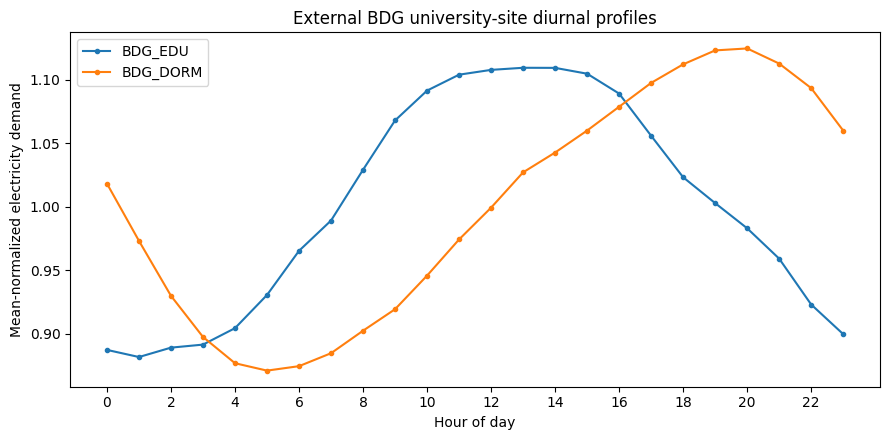

In [9]:
def descriptive_summary(name: str, export: pd.DataFrame, members: Sequence[str]) -> Dict[str, object]:
    df = export.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    y = df["Consumption"].to_numpy(dtype=float)

    hourly_profile = df.groupby(df["Date"].dt.hour)["Consumption"].mean()
    member_meta = selected_meta.loc[selected_meta["uid"].isin(members)]

    return {
        "dataset": name,
        "buildings": int(len(members)),
        "rows": int(len(df)),
        "start": df["Date"].min(),
        "end": df["Date"].max(),
        "floor_area_sqm": float(member_meta["sqm"].sum(min_count=1)),
        "demand_mean_original_unit": float(np.mean(y)),
        "demand_sd_original_unit": float(np.std(y, ddof=1)),
        "demand_cv_percent": float(np.std(y, ddof=1) / np.mean(y) * 100.0),
        "peak_hour": int(hourly_profile.idxmax()),
        "trough_hour": int(hourly_profile.idxmin()),
        "peak_trough_ratio": float(hourly_profile.max() / hourly_profile.min()),
    }


summary = pd.DataFrame([
    descriptive_summary("BDG_EDU", bdg_edu, edu_uids),
    descriptive_summary("BDG_DORM", bdg_dorm, dorm_uids),
])
display(summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, df in [("BDG_EDU", bdg_edu), ("BDG_DORM", bdg_dorm)]:
    tmp = df.copy()
    tmp["Date"] = pd.to_datetime(tmp["Date"])
    profile = tmp.groupby(tmp["Date"].dt.hour)["Consumption"].mean()
    profile = profile / profile.mean()
    ax.plot(profile.index, profile.values, marker="o", ms=3, label=label)

ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean-normalized electricity demand")
ax.set_title("External BDG university-site diurnal profiles")
ax.set_xticks(range(0, 24, 2))
ax.legend()
fig.tight_layout()
plt.show()


## 10. Freeze and audit the chronological split

BDG v1 covers one year, so the original multi-year partitions cannot be copied literally. The same chronological principle is preserved with a 6/3/3-month split. The validation interval remains long enough for the current 2:1 tuning/calibration split and 23-origin purge.

BDG v1 should **not** be used to claim that year-over-year exclusion is superior, because it does not provide an independent multi-year test of annual lags.


In [10]:
@dataclass(frozen=True)
class ExternalSplit:
    name: str
    start: pd.Timestamp
    end: pd.Timestamp


external_splits = [
    ExternalSplit("train", TRAIN_START, TRAIN_END),
    ExternalSplit("validation", VAL_START, VAL_END),
    ExternalSplit("test", TEST_START, TEST_END),
]

def count_usable_origins(split: ExternalSplit) -> Dict[str, object]:
    target_starts = pd.date_range(
        split.start,
        split.end - pd.Timedelta(hours=HORIZON),
        freq="h",
    )
    target_pos = reference_index.get_indexer(target_starts)
    target_pos = target_pos[
        (target_pos >= LOOKBACK)
        & (target_pos + HORIZON <= len(reference_index))
    ]

    return {
        "split": split.name,
        "start": split.start,
        "end_exclusive": split.end,
        "usable_origins": int(len(target_pos)),
        "first_usable_target": reference_index[target_pos[0]] if len(target_pos) else pd.NaT,
        "last_usable_target_start": reference_index[target_pos[-1]] if len(target_pos) else pd.NaT,
    }


split_audit = pd.DataFrame([count_usable_origins(s) for s in external_splits])
display(split_audit)

n_val = int(split_audit.loc[split_audit["split"].eq("validation"), "usable_origins"].iloc[0])
val_tune_n = int(math.floor(n_val * VALIDATION_TUNE_FRACTION))
val_calibration_start = val_tune_n + VALIDATION_PURGE_ORIGINS
val_calibration_n = n_val - val_calibration_start

print({
    "validation_total_origins": n_val,
    "validation_tuning_origins": val_tune_n,
    "purged_origins": VALIDATION_PURGE_ORIGINS,
    "validation_calibration_origins": val_calibration_n,
})


,split,start,end_exclusive,usable_origins,first_usable_target,last_usable_target_start
0,train,2015-01-01,2015-07-01,4153,2015-01-08,2015-06-30
1,validation,2015-07-01,2015-10-01,2185,2015-07-01,2015-09-30
2,test,2015-10-01,2016-01-01,2185,2015-10-01,2015-12-31


{'validation_total_origins': 2185, 'validation_tuning_origins': 1456, 'purged_origins': 23, 'validation_calibration_origins': 706}


## 11. Export model-ready data and reviewer-auditable provenance

The two model-ready CSVs can be added to the LASH repository in the next step. The remaining files document how the data were selected and aligned.


In [11]:
edu_path = OUTPUT_DIR / "BDG External Edu.csv"
dorm_path = OUTPUT_DIR / "BDG External Dorm.csv"

bdg_edu.to_csv(edu_path, index=False)
bdg_dorm.to_csv(dorm_path, index=False)

site_candidates.to_csv(OUTPUT_DIR / "bdg_site_candidate_ranking.csv", index=False)
cluster_membership.to_csv(OUTPUT_DIR / "bdg_selected_building_membership.csv", index=False)
meter_audit.to_csv(OUTPUT_DIR / "bdg_selected_meter_audit.csv", index=False)
weather_audit.to_csv(OUTPUT_DIR / "bdg_weather_alignment_summary.csv", index=False)
split_audit.to_csv(OUTPUT_DIR / "bdg_external_split_audit.csv", index=False)
summary.to_csv(OUTPUT_DIR / "bdg_external_descriptive_summary.csv", index=False)
schedule.to_csv(OUTPUT_DIR / "bdg_schedule_context.csv", index=False)

hourly_weather_audit = aligned_weather[[
    "timestamp",
    "weather_observation_timestamp",
    "Temp_source_timestamp", "Humi_source_timestamp", "WS_source_timestamp",
    "Temp_age_min", "Humi_age_min", "WS_age_min",
    "Temp_imputed", "Humi_imputed", "WS_imputed",
    "Temp", "Humi", "WS",
]].copy()

hourly_weather_audit.to_csv(
    OUTPUT_DIR / "bdg_hourly_weather_provenance.csv",
    index=False,
)

manifest = {
    "source": {
        "dataset": "Building Data Genome Project v1",
        "archive": str(ARCHIVE_PATH),
        "reference": "Miller and Meggers (2017), Energy Procedia 122, 439-444",
        "doi": "10.1016/j.egypro.2017.07.400",
    },
    "selection": {
        "rule": (
            "Largest metadata-defined College/University site with available shared "
            "weather and schedule files and with both educational and dormitory groups."
        ),
        "performance_used_for_selection": False,
        "selected_weather_file": selected_site["weather_file"],
        "selected_timezone": selected_site["timezone"],
        "selected_schedule_file": selected_site["schedule_file"],
        "edu_abbreviations": list(EDU_ABBREVS),
        "dorm_abbreviations": list(DORM_ABBREVS),
        "excluded_abbreviations": list(EXCLUDED_ABBREVS),
        "n_edu_buildings": len(edu_uids),
        "n_dorm_buildings": len(dorm_uids),
    },
    "weather": {
        "alignment": "backward-only source-time matching",
        "future_observed_weather_for_main_LASH": False,
        "stale_threshold_minutes": MAX_WEATHER_AGE_MIN,
        "imputation_statistics_source": "training period only",
        "training_medians": training_weather_medians,
    },
    "schedule": {
        "main_holiday_definition": "AcademicStatus == 'Holiday'",
        "break_and_summer_used_as_main_holiday": False,
    },
    "split": {
        "train": [str(TRAIN_START), str(TRAIN_END)],
        "validation": [str(VAL_START), str(VAL_END)],
        "test": [str(TEST_START), str(TEST_END)],
        "validation_tune_fraction": VALIDATION_TUNE_FRACTION,
        "validation_purge_origins": VALIDATION_PURGE_ORIGINS,
    },
    "lash_compatibility": {
        "lookback_hours": LOOKBACK,
        "horizon_hours": HORIZON,
        "required_core_columns": ["Date", "Holi", "Temp", "Humi", "WS", "Consumption"],
        "recommended_main_weather_mode": "historical_only",
        "year_over_year_external_claim": False,
    },
}

with (OUTPUT_DIR / "bdg_preprocessing_manifest.json").open("w", encoding="utf-8") as fp:
    json.dump(manifest, fp, ensure_ascii=False, indent=2, default=str)

print("Exported files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", path)


Exported files:
 - /mnt/data/outputs/BDG_v1_preprocessed/BDG External Dorm.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/BDG External Edu.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_external_descriptive_summary.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_external_split_audit.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_hourly_weather_provenance.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_preprocessing_manifest.json
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_schedule_context.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_selected_building_membership.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_selected_meter_audit.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_site_candidate_ranking.csv
 - /mnt/data/outputs/BDG_v1_preprocessed/bdg_weather_alignment_summary.csv


## 12. Final leakage and reproducibility audit

Any failure should stop the workflow before the forecasting experiment begins.


In [12]:
expected_columns = ["Date", "Holi", "Temp", "Humi", "WS", "Consumption"]

assert bdg_edu.columns.tolist() == expected_columns
assert bdg_dorm.columns.tolist() == expected_columns

edu_index = pd.DatetimeIndex(pd.to_datetime(bdg_edu["Date"]))
dorm_index = pd.DatetimeIndex(pd.to_datetime(bdg_dorm["Date"]))

assert edu_index.equals(dorm_index)
assert edu_index.equals(pd.date_range(edu_index.min(), edu_index.max(), freq="h"))
assert not bdg_edu.isna().any().any()
assert not bdg_dorm.isna().any().any()

for col in ["Temp", "Humi", "WS"]:
    source = aligned_weather[f"{col}_source_timestamp"]
    valid = source.notna()
    assert (source[valid] <= aligned_weather.loc[valid, "timestamp"]).all()

assert bool(selected_site["eligible_for_selection"])
assert TRAIN_START < TRAIN_END == VAL_START < VAL_END == TEST_START < TEST_END

audit_result = pd.DataFrame([
    {"check": "same external core schema", "passed": True},
    {"check": "complete common hourly index", "passed": True},
    {"check": "no missing core export values", "passed": True},
    {"check": "weather source timestamps are never future timestamps", "passed": True},
    {"check": "site selection uses metadata only", "passed": True},
    {"check": "chronological split frozen before model testing", "passed": True},
    {"check": "main revised experiment designated historical_only weather", "passed": True},
])

display(audit_result)
audit_result.to_csv(OUTPUT_DIR / "bdg_preprocessing_leakage_audit.csv", index=False)
print("PREPROCESSING AUDIT: PASS")


,check,passed
0,same external core schema,True
1,complete common hourly index,True
2,no missing core export values,True
3,weather source timestamps are never future tim...,True
4,site selection uses metadata only,True
5,chronological split frozen before model testing,True
6,main revised experiment designated historical_...,True


PREPROCESSING AUDIT: PASS


## 13. Integration snippet for the next LASH notebook revision

Do **not** run the full paper experiment from this preprocessing notebook. After the two external CSVs are frozen, the forecasting notebook should be modified once.

Suggested dataset specifications:

```python
"BDG_EDU": DatasetSpec(
    name="BDG External Educational Facilities",
    filename="BDG External Edu.csv",
    timestamp_format="date_string",
    timestamp_shift_hours=0,
    train_start="2015-01-01",
    train_end="2015-07-01",
    val_start="2015-07-01",
    val_end="2015-10-01",
    test_start="2015-10-01",
    test_end="2016-01-01",
    demand_unit="Original BDG v1 meter unit, aggregated",
),

"BDG_DORM": DatasetSpec(
    name="BDG External Dormitories",
    filename="BDG External Dorm.csv",
    timestamp_format="date_string",
    timestamp_shift_hours=0,
    train_start="2015-01-01",
    train_end="2015-07-01",
    val_start="2015-07-01",
    val_end="2015-10-01",
    test_start="2015-10-01",
    test_end="2016-01-01",
    demand_unit="Original BDG v1 meter unit, aggregated",
),
```

For the **revised main paper experiment**:

```python
RUN_MODE = "paper"
WEATHER_MODE = "historical_only"
DATASETS_TO_RUN = ["CLUSTER_1", "CLUSTER_2", "BDG_EDU", "BDG_DORM"]
```

### Interpretation constraints

- BDG v1 strengthens external university-oriented validation.
- BDG v1 does **not** independently validate the year-over-year exclusion decision.
- Observed target-period weather must not enter the revised headline benchmark.
- The previous observed-weather condition can be retained only as an oracle/perfect-weather sensitivity if desired.
- `Summer` and `Break` remain outside the common primary feature set unless explicitly tested.


## 14. Recommended experiment order after this preprocessing is frozen

1. Make `historical_only` the primary weather condition for every method.
2. Add BDG-Edu and BDG-Dorm as external datasets.
3. Add the requested tree ensembles (LightGBM, XGBoost, GBM, CatBoost) using a causally valid direct 24-step design.
4. Report model-specific HPO spaces, repeated search seeds, training time, latency, and memory/parameter statistics.
5. Sensitivity-test the current router and compare it with simpler constrained blending/NNLS alternatives.
6. Rerun matched ablations under comparable tuning budgets.
7. Disaggregate the year-over-year ablation on the original long-history datasets only.
8. Perform HAC/block-length sensitivity and seed-aware inference.
9. Add a peak-oriented BEMS operational analysis.
10. Only after the numerical results are frozen, update the manuscript, figures, conclusions, and point-by-point reviewer responses.

This ordering prevents repeated manuscript rewrites while headline metrics are still changing.
